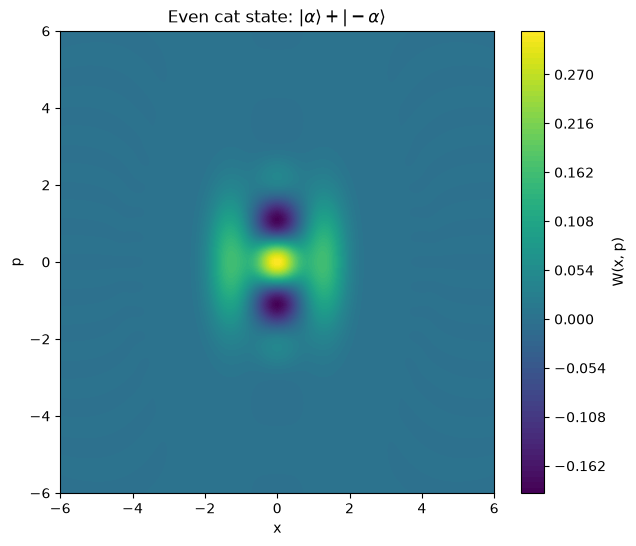

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# Fock-space cutoff
N = 40
# Cat amplitude
alpha = 1.5
# squeezing 
r = 0.5

vaccuum = qt.coherent(N,0)
# Construct the coherent states |alpha> and |-alpha>
ket_plus = qt.coherent(N, alpha)
ket_minus = qt.coherent(N, -alpha)

# Even cat state
cat = (ket_plus + ket_minus).unit()

# squeezing operator
S = qt.squeeze(N,r)

#squeezed cat
SC = S*cat


# two cats
cat2 = qt.tensor(SC,SC)

# Phase-space grid
xvec = np.linspace(-6, 6, 300)
pvec = np.linspace(-6, 6, 300)

# Calculate Wigner function
W = qt.wigner(SC, xvec, pvec)

# Plot
plt.figure(figsize=(7, 6))
plt.contourf(xvec, pvec, W, levels=100)
plt.colorbar(label="W(x, p)")
plt.xlabel("x")
plt.ylabel("p")
plt.title(r"Even cat state: $|\alpha\rangle + |-\alpha\rangle$")
plt.show()

In [3]:
# beamsplitter on 2 squeezed cats 

a1 = qt.tensor(qt.destroy(N), qt.qeye(N))
a2 = qt.tensor(qt.qeye(N), qt.destroy(N))

# 50/50 beam splitter angle (theta = pi/4, phi = pi/2)
theta = np.pi / 4
phi = np.pi / 2

# Interaction operator for the beam splitter
H_bs = theta * (a1.dag() * a2 * np.exp(-1j * phi) + a1 * a2.dag() * np.exp(1j * phi))
U_bs = H_bs.expm()  # Unitary operator

# input state 
psi0 = qt.tensor(cat,cat)

# apply beamsplitter
psi_out = U_bs * psi0

In [4]:
C = psi_out.full().reshape(N, N)

print(C.shape)

(40, 40)


In [7]:
p_meas = np.linspace(-8, 8, 2000)
def momentum_fock_wavefunctions(p_grid, N):
    phi = np.zeros((len(p_grid), N), dtype=complex)

    for n in range(N):
        prefactor = (
            1 /
            (np.pi**0.25 * np.sqrt(2**n * factorial(n)))
        )

        phi[:, n] = (
            (-1j)**n
            * prefactor
            * eval_hermite(n, p_grid)
            * np.exp(-p_grid**2 / 2)
        )

    return phi

phi = momentum_fock_wavefunctions(p_meas, N)

print(phi.shape)

(2000, 40)


In [9]:
conditional_unnorm = phi @ C
print(conditional_unnorm.shape)

(2000, 40)


PDF integral before normalization: 870.608822210763
PDF min: 9.993340113554525e-10
PDF max: 242.5265787602945
PDF integral after normalization: 1.0
Normalized PDF max: 0.27857123954296664


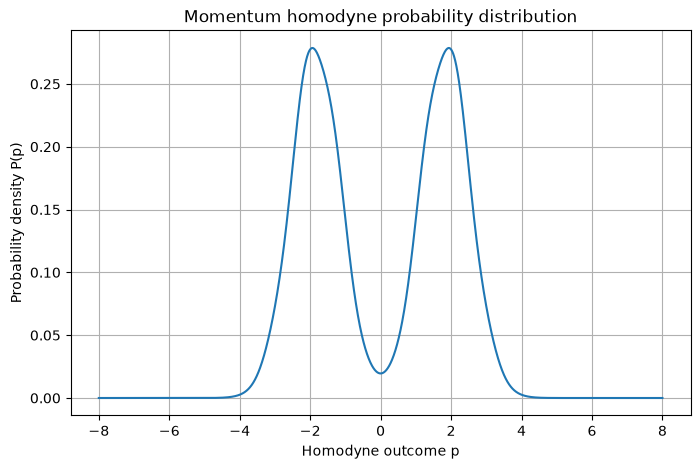

Vacuum PDF integral: 1.0


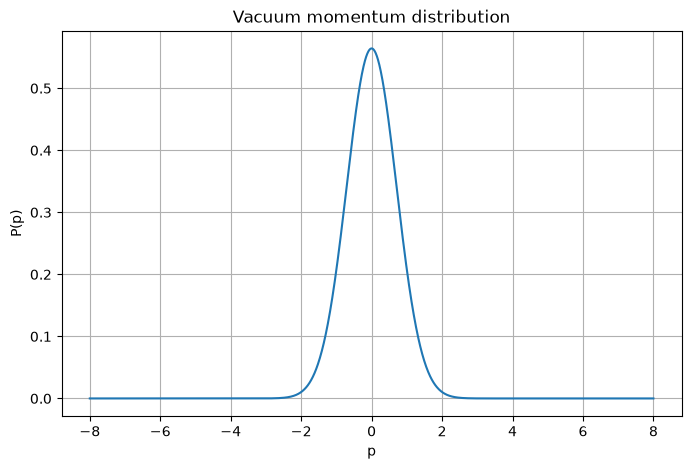

In [14]:
pdf = np.sum(
    np.abs(conditional_unnorm)**2,
    axis=1
)
print("PDF integral before normalization:",
      np.trapezoid(pdf, p_meas))

print("PDF min:", pdf.min())
print("PDF max:", pdf.max())
pdf = pdf / np.trapezoid(pdf, p_meas)
print("PDF integral after normalization:",
      np.trapezoid(pdf, p_meas))

print("Normalized PDF max:", pdf.max())

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(p_meas, pdf)
plt.xlabel("Homodyne outcome p")
plt.ylabel("Probability density P(p)")
plt.title("Momentum homodyne probability distribution")
plt.grid()
plt.show()

vacuum_pdf = np.abs(phi[:, 0])**2

print(
    "Vacuum PDF integral:",
    np.trapezoid(vacuum_pdf, p_meas)
)

plt.figure(figsize=(8, 5))
plt.plot(p_meas, vacuum_pdf)
plt.xlabel("p")
plt.ylabel("P(p)")
plt.title("Vacuum momentum distribution")
plt.grid()
plt.show()

In [11]:
pdf /= np.trapezoid(pdf, p_meas)
print(np.trapezoid(pdf, p_meas))

1.0


In [15]:
rng = np.random.default_rng(1234)

cdf = cumulative_trapezoid(
    pdf,
    p_meas,
    initial=0
)

cdf /= cdf[-1]

u = rng.random()

p_sample = np.interp(
    u,
    cdf,
    p_meas
)

print("Random number u =", u)
print("Sampled homodyne outcome =", p_sample)

NameError: name 'cumulative_trapezoid' is not defined